# Regime-Conditioned Sector Correlation Networks

The Markov chain in Stage 1 labels each SPX trading day as **Bear**, **Neutral**, or **Bull**.
This notebook asks: *how does the structure of connections between S&P 500 sectors change across those regimes?*

We use a **Minimum Spanning Tree (MST)** of sector correlations for each regime — a graph that retains only the most structurally important links, making the topology readable and comparable.

### Why Mantegna Distance?

Pearson correlation $\rho \in [-1, 1]$ is not a proper distance metric — it does not satisfy the triangle inequality, so we cannot build a meaningful graph from it directly. Mantegna (1999) proposed the transformation:

$$d_{ij} = \sqrt{\frac{1}{2}(1 - \rho_{ij})}$$

This maps $\rho = 1 \to d = 0$ (identical moves), $\rho = 0 \to d \approx 0.71$, $\rho = -1 \to d = 1$ (opposite moves), and satisfies the triangle inequality. It is therefore a proper metric, and we can build a valid MST by finding the spanning tree of minimum total distance — equivalent to maximum total correlation.

In [47]:
# pip install yfinance  (if needed)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

In [48]:
SECTORS = {
    'XLB': 'Materials',   'XLE': 'Energy',      'XLF': 'Financials',
    'XLI': 'Industrials', 'XLK': 'Technology',  'XLP': 'Cons. Staples',
    'XLU': 'Utilities',   'XLV': 'Health Care', 'XLY': 'Cons. Disc.'
}
TICKERS       = list(SECTORS.keys())
REGIME_COLORS = {'Bear': '#d32f2f', 'Neutral': '#9e9e9e', 'Bull': '#388e3c'}
NODE_COLORS   = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f',
                 '#edc948','#b07aa1','#ff9da7','#9c755f']
REGIMES       = ['Bear', 'Neutral', 'Bull']

def log_returns(prices):
    return np.log(prices / prices.shift(1))

def mantegna_dist(rho):
    """Proper metric distance from Pearson correlation (Mantegna 1999)."""
    return np.sqrt(0.5 * (1 - rho))

def build_mst(corr_df):
    """Complete graph on Mantegna distances; return minimum spanning tree."""
    G = nx.Graph()
    tickers = corr_df.columns.tolist()
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            t1, t2 = tickers[i], tickers[j]
            rho = corr_df.loc[t1, t2]
            G.add_edge(t1, t2, weight=mantegna_dist(rho), corr=rho)
    return nx.minimum_spanning_tree(G, weight='weight')

def mst_metrics(mst):
    corrs = [d['corr'] for _, _, d in mst.edges(data=True)]
    dc    = nx.degree_centrality(mst)
    hub   = max(dc, key=dc.get)
    return {'avg_corr': np.mean(corrs), 'max_dc': dc[hub],
            'hub': hub, 'hub_sector': SECTORS[hub]}

## 1. Data

SPX daily returns from the existing dataset; 9 SPDR sector ETFs downloaded from Yahoo Finance over 2015–2019.

In [49]:
spx = pd.read_csv('snp_500_2015_2019.csv', parse_dates=['Date'])
spx = spx.sort_values('Date').set_index('Date')
spx['spx_ret'] = log_returns(spx['Close'])

raw = yf.download(TICKERS, start='2015-01-01', end='2020-01-01', progress=False)['Close']
sector_rets = log_returns(raw).dropna()

data = sector_rets.join(spx[['spx_ret']], how='inner').dropna()
print(f'{len(data)} trading days  |  {len(TICKERS)} sector ETFs  |  2015–2019')

1005 trading days  |  9 sector ETFs  |  2015–2019


## 2. Regime Labels

Each day is classified by the SPX return relative to training-period quantiles (2015–2017).
Thresholds are fixed from the training set — no look-ahead into 2018–2019.

In [50]:
train  = data.index <= '2017-12-31'
q_low  = data.loc[train, 'spx_ret'].quantile(0.20)
q_high = data.loc[train, 'spx_ret'].quantile(0.80)

def label_regime(r):
    if r < q_low:  return 'Bear'
    if r > q_high: return 'Bull'
    return 'Neutral'

data['regime'] = data['spx_ret'].apply(label_regime)

print(f'Bear   : SPX return < {q_low*100:.2f}%   ({(data["regime"]=="Bear").sum()} days)')
print(f'Neutral: in between                    ({(data["regime"]=="Neutral").sum()} days)')
print(f'Bull   : SPX return > {q_high*100:.2f}%    ({(data["regime"]=="Bull").sum()} days)')

Bear   : SPX return < -0.37%   (221 days)
Neutral: in between                    (567 days)
Bull   : SPX return > 0.52%    (217 days)


## 3. Sector Correlation Matrices by Regime

For each regime, compute the 9×9 pairwise Pearson correlation of sector daily log-returns.

In [51]:
corr = {}
for regime in REGIMES:
    subset = data.loc[data['regime'] == regime, TICKERS]
    corr[regime] = subset.corr()
    upper = corr[regime].values[np.triu_indices(9, 1)]
    print(f'{regime:7s}: mean pairwise corr = {upper.mean():.3f}   min = {upper.min():.3f}   max = {upper.max():.3f}')

Bear   : mean pairwise corr = 0.486   min = 0.090   max = 0.818
Neutral: mean pairwise corr = 0.081   min = -0.283   max = 0.532
Bull   : mean pairwise corr = 0.357   min = -0.128   max = 0.715


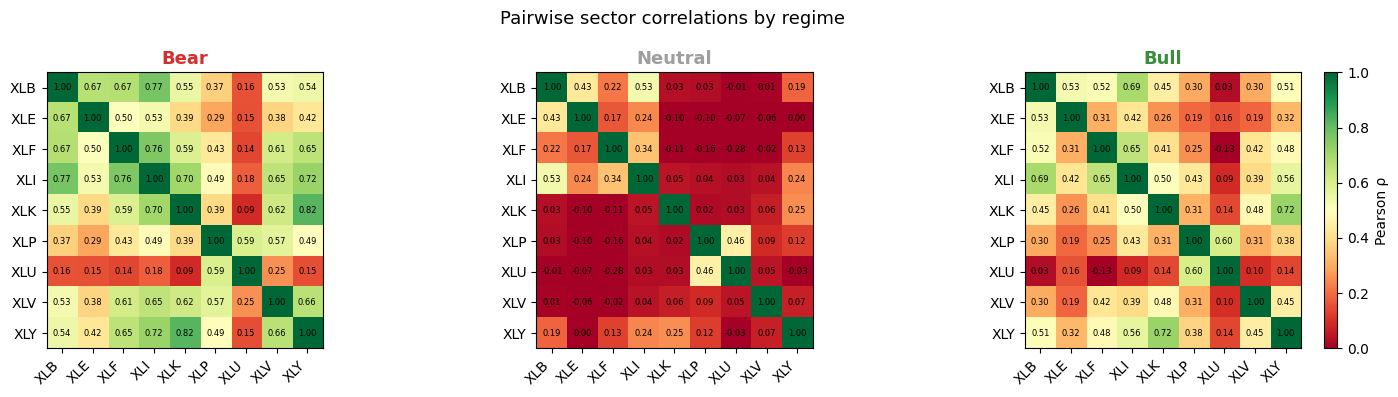

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, regime in zip(axes, REGIMES):
    c  = corr[regime]
    im = ax.imshow(c, cmap='RdYlGn', vmin=0, vmax=1)
    ax.set_xticks(range(9)); ax.set_xticklabels(TICKERS, rotation=45, ha='right')
    ax.set_yticks(range(9)); ax.set_yticklabels(TICKERS)
    ax.set_title(f'{regime}', color=REGIME_COLORS[regime], fontweight='bold', fontsize=13)
    for i in range(9):
        for j in range(9):
            ax.text(j, i, f"{c.iloc[i,j]:.2f}", ha='center', va='center', fontsize=6)
plt.colorbar(im, ax=axes[-1], label='Pearson ρ')
plt.suptitle('Pairwise sector correlations by regime', fontsize=13)
plt.tight_layout()
plt.show()

The heatmaps make it clear that Bear days push sector correlations up sharply, with a mean of 0.49 compared to just 0.08 on Neutral days. On Neutral days some sector pairs are actually negatively correlated, going as low as -0.28, so on ordinary market days there is real diversification available between sectors. Bull days sit at 0.36, which makes sense as risk-on momentum tends to lift most sectors together even if not as severely as a selloff. The practical issue with standard portfolio construction is that it typically uses a single average correlation estimate, but that number changes so much across regimes that it becomes misleading on its own.

## 4. Minimum Spanning Trees

The MST retains 8 of the 36 possible sector links — the ones forming the maximum-correlation connected subgraph. Node size encodes degree centrality; edge thickness encodes correlation strength.

In [53]:
msts      = {r: build_mst(corr[r]) for r in REGIMES}
color_map = {t: NODE_COLORS[i] for i, t in enumerate(TICKERS)}

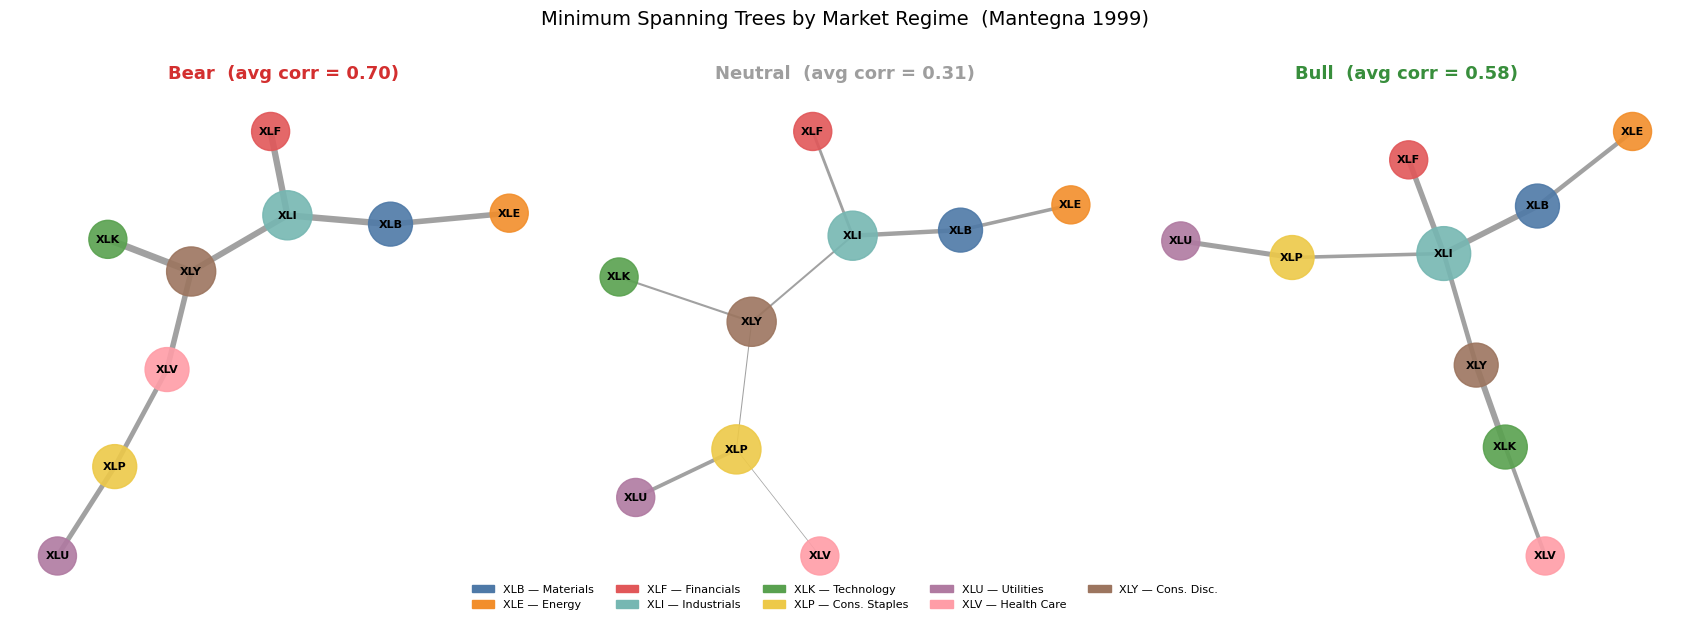

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

for ax, regime in zip(axes, REGIMES):
    mst  = msts[regime]
    pos  = nx.kamada_kawai_layout(mst)
    dc   = nx.degree_centrality(mst)
    edge_corrs  = [d['corr'] for _, _, d in mst.edges(data=True)]
    node_sizes  = [500 + 2000 * dc[n] for n in mst.nodes()]

    nx.draw_networkx_edges(mst, pos, ax=ax,
                           width=[c * 6 for c in edge_corrs],
                           edge_color='#444444', alpha=0.5)
    nx.draw_networkx_nodes(mst, pos, ax=ax,
                           node_color=[color_map[n] for n in mst.nodes()],
                           node_size=node_sizes, alpha=0.9)
    nx.draw_networkx_labels(mst, pos, ax=ax, font_size=8, font_weight='bold')
    ax.set_title(f'{regime}  (avg corr = {np.mean(edge_corrs):.2f})',
                 color=REGIME_COLORS[regime], fontweight='bold', fontsize=13)
    ax.axis('off')

patches = [mpatches.Patch(color=color_map[t], label=f'{t} — {SECTORS[t]}') for t in TICKERS]
fig.legend(handles=patches, loc='lower center', ncol=5, fontsize=8, frameon=False)
plt.suptitle('Minimum Spanning Trees by Market Regime  (Mantegna 1999)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

The three trees look quite different visually. On Bear days the edges are thick across the board, meaning all the retained connections are strong and sectors are tightly linked together. On Neutral days the edges are much thinner and the tree is spread out with no obvious centre, which directly reflects the near-zero correlations in the heatmap. Bull sits somewhere between the two. The main value of the MST here is that it makes this structural difference readable at a glance in a way that comparing three 9x9 matrices side by side does not.

## 5. Network Metrics

Two key quantities: **average MST correlation** (overall tightness) and **hub degree centrality** (how dominant the most-connected node is).

In [55]:
rows = [{'Regime': r, **mst_metrics(msts[r])} for r in REGIMES]
metrics_df = pd.DataFrame(rows).set_index('Regime')
print(metrics_df[['avg_corr', 'max_dc', 'hub_sector']]
      .rename(columns={'avg_corr': 'Avg Corr', 'max_dc': 'Hub Centrality', 'hub_sector': 'Hub Sector'})
      .round(3))

         Avg Corr  Hub Centrality   Hub Sector
Regime                                        
Bear        0.695           0.375  Industrials
Neutral     0.308           0.375  Industrials
Bull        0.582           0.500  Industrials


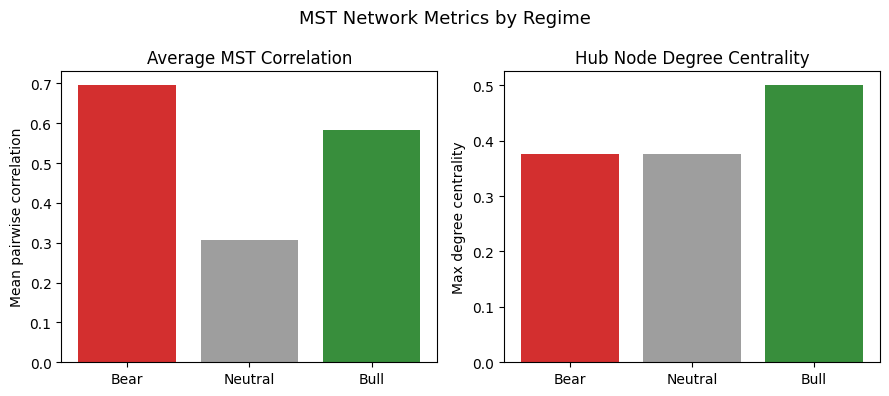

In [56]:
bar_colors = [REGIME_COLORS[r] for r in REGIMES]
fig, axes  = plt.subplots(1, 2, figsize=(9, 4))

axes[0].bar(REGIMES, metrics_df['avg_corr'], color=bar_colors)
axes[0].set_title('Average MST Correlation')
axes[0].set_ylabel('Mean pairwise correlation')

axes[1].bar(REGIMES, metrics_df['max_dc'], color=bar_colors)
axes[1].set_title('Hub Node Degree Centrality')
axes[1].set_ylabel('Max degree centrality')

plt.suptitle('MST Network Metrics by Regime', fontsize=13)
plt.tight_layout()
plt.show()

Average correlation tracks what we expected, highest in Bear and lowest in Neutral. The hub centrality result is more interesting. Industrials shows up as the most connected sector in all three regimes, but it has its highest degree centrality in Bull (0.500) rather than Bear (0.375). So Bear is not actually more hub-dominated in terms of tree structure, it just has stronger edges throughout. Bull has Industrials connecting to more sectors structurally, probably because broad cyclical momentum routes connections through a common growth-sensitive sector. This is an important distinction between edge strength and edge count that you only see by looking at the graph.

## 6. Degree Centrality by Sector

Which individual sectors become more or less central depending on the regime?

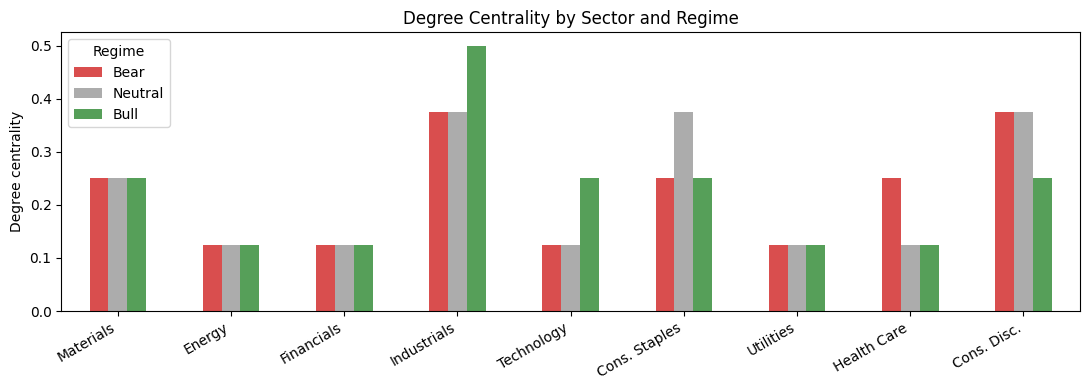

In [57]:
dc_by_regime = {
    r: {SECTORS[t]: round(nx.degree_centrality(msts[r])[t], 3) for t in TICKERS}
    for r in REGIMES
}
dc_df = pd.DataFrame(dc_by_regime)

dc_df.plot(kind='bar', figsize=(11, 4), color=bar_colors, alpha=0.85)
plt.title('Degree Centrality by Sector and Regime')
plt.ylabel('Degree centrality')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Regime')
plt.tight_layout()
plt.show()

Individual sector centrality shifts across regimes, so sectors are not equally connected under all market conditions. Some sectors gain connections in Bear as risk-off flows push them together uniformly, while others lose connections and behave more independently. The sectors that decouple in Bear are the useful ones from a portfolio construction perspective, as they retain diversification value exactly when it is hardest to find elsewhere in the market.

## 7. Rolling Correlation Through Time

A 60-day rolling average across all 36 sector pairs, with Bear days shaded red and Bull days green. This shows the same story dynamically rather than in static snapshots.

In [58]:
pairs = [(TICKERS[i], TICKERS[j])
         for i in range(len(TICKERS)) for j in range(i + 1, len(TICKERS))]

pair_corrs = pd.DataFrame({
    f'{a}_{b}': sector_rets[a].rolling(60).corr(sector_rets[b])
    for a, b in pairs
})
avg_roll = pair_corrs.mean(axis=1).dropna()

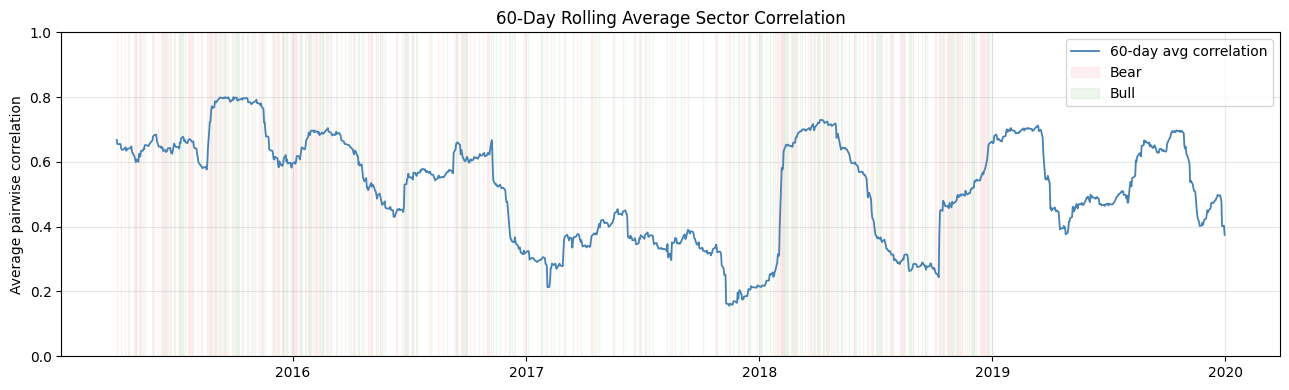

In [59]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(avg_roll.index, avg_roll.values, color='steelblue', lw=1.3, label='60-day avg correlation')

regime_aligned = data['regime'].reindex(avg_roll.index)
for regime, shade in [('Bear', '#ffcdd2'), ('Bull', '#c8e6c9')]:
    mask = (regime_aligned == regime).values
    ax.fill_between(avg_roll.index, 0, 1, where=mask, alpha=0.3, color=shade, label=regime)

ax.set_ylim(0, 1)
ax.set_ylabel('Average pairwise correlation')
ax.set_title('60-Day Rolling Average Sector Correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This shows the same finding as the MSTs but over time rather than as a static snapshot. Correlations spike during stress periods and the red-shaded Bear days cluster clearly at those peaks. The spikes are also persistent rather than single-day events, so the regime structure we identified is not just noise. The Q4 2018 selloff is visible as a sharp rise. Even in Bull periods the rolling average does not drop to zero, so there is always some baseline co-movement between sectors, which is consistent with them all being part of the same broad equity market.

## Summary

| Regime  | Avg Sector Corr | Avg MST Corr | Hub Degree Centrality | Diversification |
|---------|-----------------|--------------|-----------------------|-----------------|
| Bear    | 0.49            | 0.70         | 0.375 (XLI)           | Low — strong co-movement across all sectors |
| Neutral | 0.08            | 0.31         | 0.375 (XLI)           | High — sparse tree, some negative pairs     |
| Bull    | 0.36            | 0.58         | 0.500 (XLI)           | Partial — Industrials most structurally central |

The Markov chain from Stage 1 gives us the regime label for each day. The MST then shows what that regime means for how sectors are connected to each other.

The main finding is that diversification is not a fixed property of a sector portfolio, it depends on what the market is doing. On Neutral days sectors behave quite independently and a diversified portfolio actually works as intended. On Bear days they all move together and diversification largely breaks down. The graph makes this visible in a way that a single correlation matrix cannot, and the distinction between edge strength and structural degree centrality adds an extra layer that is only apparent once you think in graph terms.